<a href="https://colab.research.google.com/github/mingshey/python_EM/blob/main/%EC%A0%84%EA%B8%B0%EB%A0%A5%EC%84%A0%EA%B3%BC_%EB%93%B1%EC%A0%84%EC%9C%84%EC%84%A0_streamplot%EC%98%88%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
2차원 평면에 임의의 전하 배치에 대한
전기력선과 등전위면을 그리는 과정입니다.
"""
import matplotlib.pyplot as plt
import numpy as np

pi = np.pi

In [ ]:
def is_on_a_charge(clist, pos):
    """
    주어진 위치에 전하가 있는지 검사하는 함수
    clist:  전하 목록
    pos: 검사할 위치
    """

    for c in clist:
        if ((pos[0] == c[1]) and (pos[1] == c[2])):
            return True

In [ ]:
def norm(vec:np.ndarray):
  """
  벡터의 크기(norm)을 반환한다.
  """
  return np.sqrt((vec * vec).sum(axis=0))

def potential_1(charge, pos):
    """
    주어진 위치(pos)에서 한 개의 전하(charge)에 의한 전기 퍼텐셜을 구한다.
    """
    dr = pos - charge[1:]
    r = norm(dr)
    p = charge[0] / r
    return p

def potential(pos):
    """
    주어진 위치에서 charges 안의 모든 전하에 의한 전기 퍼텐셜의 합을 구한다.
    """
    global charges
    if is_on_a_charge(charges, pos): # 특이점(±∞)을 피하기 위해 전하가 위치한 곳은 생략한다.
        return 0
    p = 0

    for c in charges:
        p = p + potential_1(c, pos)
    return p

In [ ]:
def E_field_1(charge:tuple, pos:tuple):
    """
    주어진 위치(pos)에서 한 개의 전하(charge)에 의한 전기장 벡터를 구한다.
    """
    dr = pos - charge[1:]
    r = norm(dr)
    e = charge[0] / (r ** 3) * dr
    return e

def E_field(pos:tuple):
    """
    주어진 위치(pos)에서 전하 목록 전체에 의한 전기장의 합을 구한다.
    """
    global charges
    if is_on_a_charge(charges, pos): # 특이점을 피하기 위해 전하가 위치한 곳은 생략한다.
        return np.array([0, 0])
    e = np.array([0, 0])

    for c in charges:
        e = e + E_field_1(c, pos)
    return e

In [ ]:
def dir_field(pos):
    """
    방향장, 즉 주어진 전기장 벡터 방향의 단위 벡터를 구한다.
    단, 0 벡터에 대해서는 0 벡터를 반환한다.
    """
    e = E_field(pos)
    abse = np.sqrt(e[0] * e[0] + e[1] * e[1])
    if (abse == 0):
        return e
    else:
        return e / abse

In [ ]:
config_name="default" # 아래 전하 분포에 대한 식별자. 출력 파일 이름에 사용
Q=1.0             # 단위 전하
q1 = 2*Q          # 전하 1
q2 = -1*Q         # 전하 2
# q3 = 2*Q
# q4 = -Q
a = 1             # 좌표 원점에서 한 전하까지의 거리
x1, y1 = -a, 0  # 전하 1의 위치
x2, y2 = a, 0   # 전하 2의 위치

#k=9.0e9        # 쿨롱 상수는 편의상 1로 둔다.

charges = np.array([])    # 전하 목록 초기화

# 임의의 갯수만큼 전하를 추가
charges = np.append(charges, [q1, x1, y1])  # 첫 번째 전하
charges = np.append(charges, [q2, x2, y2]) # 두 번째 전하

# 전하 한 개에 대해 노트북을 끝까지 실행해 본 뒤,
# 위 두번째 전하를 추가하는 줄의 코멘트를 해제하여 전하 2개인 경우에 대해 다시 실행해 봅니다.
# 그런 다음 원하는 대로 전하의 크기와 부호, 위치를 변경하거나
# 새로운 전하를 추가하여 전기장의 모습을 비교해 보고
# 손으로 계산한 결과와 비교하여 스스로를 납득시켜 봅니다.

#...

# 마지막으로 전하 목록의 배열 형태를 취급하기 좋게 변경해 준다.
# 아래 줄을 코멘트 처리해 보고 reshape를 하지 않으면 charges가 어떤 모습이 되는지 비교해 봅니다.
# reshape 이 필요하지 않도록 하려면 전하를 추가하는 과정을 어떻게 바꾸면 될까요?
charges = charges.reshape(-1, 3)

In [ ]:
charges

array([[ 2., -1.,  0.],
       [-1.,  1.,  0.]])

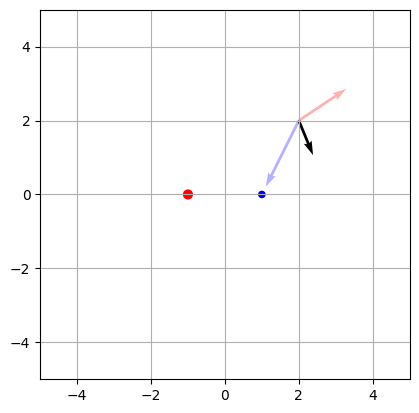

In [ ]:
X, Y = (2,2)  # 전기장을 구하고자 하는 위치 (xy-좌표)
'''
 전기장 벡터들을 크기에 비례하게 그린다.
 화살표들이 너무 길어서 뒤엉키거나 너무 작아
 알아보기 어려운 것을 알 수 있다.
'''
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)
plt.grid()
plt.xlim([-5,5])
plt.ylim([-5,5])

Ex1, Ey1 = E_field_1(charges[0], (X, Y))
Ex2, Ey2 = E_field_1(charges[1], (X, Y))

mc = ['r' if c[0]>0 else 'b' for c in charges ]             # 전하의 색깔 (marker color)
ms = [np.abs(c[0])*40/charges.T[0].max() for c in charges]  # 전하의 크기 (marker size)

plt.quiver(X, Y, Ex1, Ey1, color=mc[0], scale_units='xy', scale=.1, angles='xy', alpha=0.3)  # 전기장 벡터
plt.quiver(X, Y, Ex2, Ey2, color=mc[1], scale_units='xy', scale=.1, angles='xy', alpha=0.3)  # 전기장 벡터
plt.quiver(X, Y, Ex1+Ex2, Ey1+Ey2, color='k', scale_units='xy', scale=.1, angles='xy')  # 전기장 벡터

plt.scatter(charges[:, 1], charges[:, 2], color=mc, s = ms) # 전하
#savefig("EF" + config_name +".svg")  # SVG 포맷으로 그림을 저장한다.

In [ ]:
rad = 4 * a
xmin, xmax = -rad, rad
ymin, ymax = -rad, rad

rad2 = rad
xlist = np.linspace(-rad2, rad2, 80)
ylist = np.linspace(-rad2, rad2, 80)
xm, ym = np.meshgrid(xlist, ylist)

xlist2 = np.linspace(-3, 3, 7)
ylist2 = np.linspace(-2, 2, 5)
xm2, ym2 = np.meshgrid(xlist2, ylist2)

# 전기장 벡터들의 배열
e = [[E_field(np.array([x, y])) for x in xlist] for y in ylist]
e2 = [[E_field(np.array([x, y])) for x in xlist2] for y in ylist2]

# 전기장 벡터들의 x, y 성분 배열
ex = np.array([[ev[0] for ev in evecs] for evecs in e])
ey = np.array([[ev[1] for ev in evecs] for evecs in e])

ex2 = np.array([[ev[0] for ev in evecs] for evecs in e2])
ey2 = np.array([[ev[1] for ev in evecs] for evecs in e2])

# 방향 벡터(전기장 방향 단위 벡터)들의 배열
d = [[dir_field(np.array([x, y])) for x in xlist] for y in ylist]

d2 = [[dir_field(np.array([x, y])) for x in xlist2] for y in ylist2]

# 방향 벡터들의 x, y 성분 배열
dx = np.array([[10.0 * dv[0] for dv in dvecs] for dvecs in d])
dy = np.array([[10.0 * dv[1] for dv in dvecs] for dvecs in d])

dx2 = np.array([[10.0 * dv[0] for dv in dvecs] for dvecs in d2])
dy2 = np.array([[10.0 * dv[1] for dv in dvecs] for dvecs in d2])

# 전위값의 배열
phis = [[potential(np.array([x, y])) for x in xlist] for y in ylist]

mc = ['r' if c[0]>0 else 'b' for c in charges ]             # 전하의 색깔 (marker color)
ms = [np.abs(c[0])*40/charges.T[0].max() for c in charges]  # 전하의 크기 (marker size)

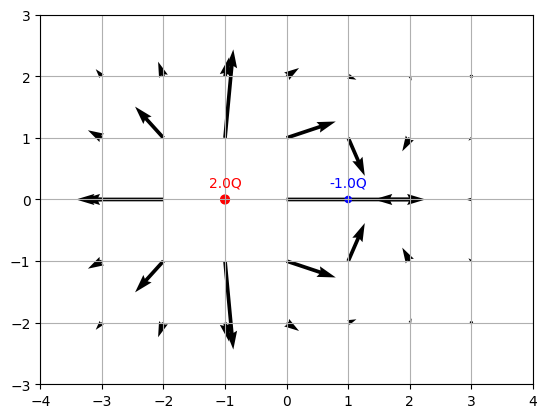

In [ ]:
'''
 전기장 벡터들을 크기에 비례하게 그린다.
 화살표들이 너무 길어서 서로 뒤엉키거나 너무 작아
 알아보기 어려운 것을 알 수 있다.
'''
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)

plt.xlim([-4,4])
plt.ylim([-3,3])

plt.grid()
plt.quiver(xm2, ym2, ex2, ey2)  # 전기장 벡터

for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')

plt.scatter(charges[:, 1], charges[:, 2], color=mc, s = ms) # 전하
plt.savefig("EF-" + config_name +".svg")  # SVG 포맷으로 그림을 저장한다.

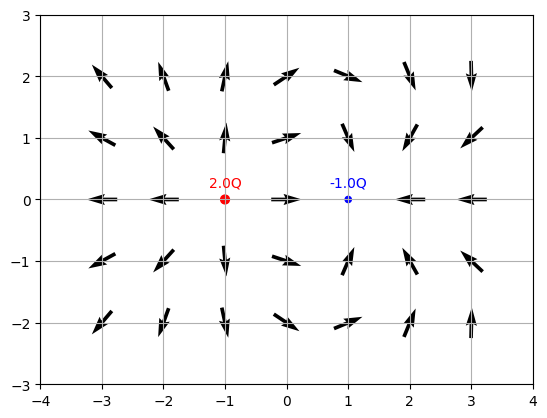

In [ ]:
'''
 전기장의 방향만을 일정한 크기로 그린다.
 전기장의 방향 분포만을 나타낼 수 있다는 한계가 있지만
 전체적인 전기장의 방향 분포를 알아보기 편리하다.
'''
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)

plt.grid()

plt.xlim([-4,4])
plt.ylim([-3,3])
plt.quiver(xm2, ym2, dx2, dy2, angles = 'xy', scale_units = 'xy', scale=20, pivot='mid') # 방향 벡터

plt.scatter(charges[:, 1], charges[:, 2], color=mc, s = ms) # 전하
for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')

# plt.text(charges[0,1], charges[0,2]+0.2, str(charges[0,0])+'Q', horizontalalignment='center')
# plt.text(charges[1,1], charges[1,2]+0.2, str(charges[1,0])+'Q', horizontalalignment='center')
plt.savefig("DF-" + config_name +".svg")  # SVG 포맷으로 그림을 저장한다.

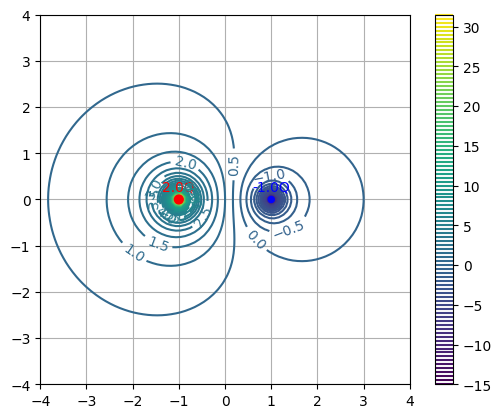

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)

plt.grid()

# 등고선 그래프(등전위선)
CS = plt.contour(xm, ym, phis, levels=100)
plt.colorbar()

# 등전위선에 값을 표시
plt.clabel(CS, inline=True, fontsize=10)

plt.scatter(charges[:, 1], charges[:, 2], color=mc, s = ms, zorder=2) # 전하

for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')

#plt.savefig("CS-" + config_name +".svg")  # SVG 포맷으로 그림을 저장한다.

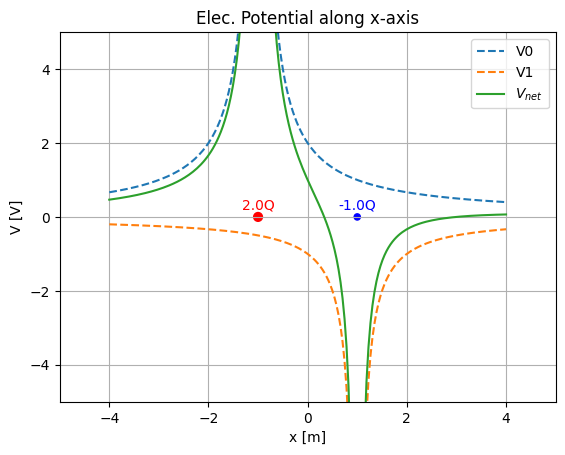

In [ ]:
xs = np.linspace(-rad2, rad2, 200)
ys = np.zeros(xs.shape)

Vis = [[potential_1(c, pos) for pos in np.array([xs, ys]).T] for c in charges]
Vs = [potential(pos) for pos in np.array([xs, ys]).T]

plt.grid()
plt.title("Elec. Potential along x-axis")
plt.xlim([-5, 5])
plt.ylim([-5, 5])
plt.xlabel("x [m]")
plt.ylabel("V [V]")

# 전하가 2개 이상이면
# 각각의 전하에 의한 전위 그래프를 파선(dashed line, "- - -")으로 그린다.
if len(charges) > 1:
  for i in range(len(charges)):
    plt.plot(xs, Vis[i], ls='dashed', label=f"V{i:d}") # 전위 그래프

plt.plot(xs, Vs, label = r"$V_{net}$")   # 합성 전위

plt.scatter(charges[:, 1], np.zeros(charges[:,2].shape), c=mc, s = ms) # 전하

for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')

plt.legend()
plt.savefig("VX-" + config_name +".svg")

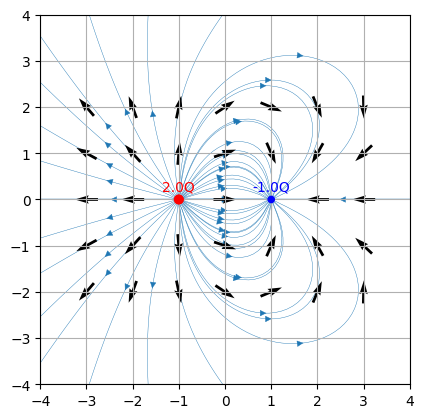

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)

plt.xlim([-rad2,rad2])
plt.ylim([-rad2,rad2])

plt.grid()
#전기장의 크기 배열
Emag = np.sqrt(ex**2 + ey**2)

# 전기력선 시작 위치
list1 = [[(c[1] + .1 * a * np.cos(th), c[2] + .1 * a * np.sin(th)) \
       for th in np.arange(-pi, pi, pi/(8 * np.fabs(c[0])))] for c in charges]

sps = np.empty((0,2))
for i in range(len(list1)):
  sps = np.append(sps, list1[i], axis=0)

# 전기력선
plt.streamplot(xm, ym, ex, ey, \
               linewidth=0.3, density=2, \
               broken_streamlines=False, \
               start_points=sps, zorder=0)

# 전기장 방향 샘플
plt.quiver(xm2, ym2, dx2, dy2, angles = 'xy', scale_units = 'xy', \
           scale=20, pivot='mid', zorder=1) # 방향 벡터

# 전하
plt.scatter(charges.T[1], charges.T[2], c = mc, s = ms, zorder=2) # 전하

for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')

plt.savefig("FL-" + config_name +"a.svg")  # SVG 포맷으로 그림을 저장.

아래 그림과 비교해 봅시다

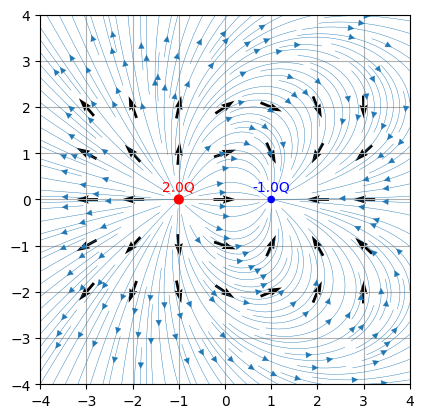

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)

plt.xlim([-rad2,rad2])
plt.ylim([-rad2,rad2])

plt.grid()

# 전기력선
plt.streamplot(xm, ym, ex, ey, \
               linewidth=0.3, density=2, \
               broken_streamlines=True)

# 전기장 방향 샘플
plt.quiver(xm2, ym2, dx2, dy2, angles = 'xy', scale_units = 'xy', scale=20, pivot='mid', zorder=1) # 방향 벡터

# 전하
plt.scatter(charges.T[1], charges.T[2], c = mc, s = ms, zorder=2)

for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')

plt.savefig("FL-" + config_name +"b.svg")

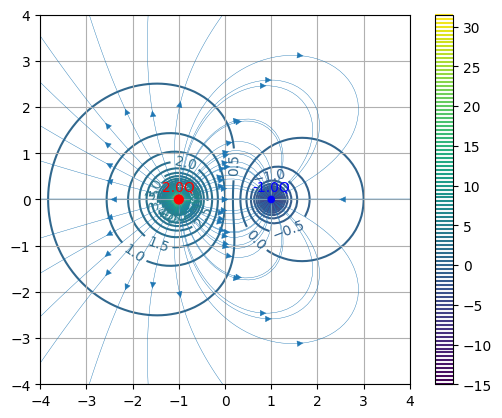

In [ ]:
fig, ax = plt.subplots()
ax.set_aspect(aspect=1)

plt.xlim([-rad2, rad2])
plt.ylim([-rad2, rad2])

plt.grid()

# 등전위선
CS = plt.contour(xm, ym, phis, levels=100, zorder=1) # 등전위선을 그린다.
plt.colorbar() # 등전위선 컬러 코드

#등전위선 레이블(전위 값)
ax.clabel(CS, inline=True, fontsize=10)

# 전기력선
# plt.streamplot(xm, ym, ex, ey, \
#                linewidth=0.3, density=2, \
#                broken_streamlines=True, zorder=0)

# 옵션을 달리하여 전기력선을 그리는 방식을 바꿔본다:
plt.streamplot(xm, ym, ex, ey, \
               linewidth=0.3, density=2, \
               broken_streamlines=False, start_points=sps)

# 전하
plt.scatter(charges.T[1], charges.T[2], c = mc, s = ms, zorder = 2)

for c in charges:
  plt.text(c[1], c[2]+0.2, str(c[0])+'Q', horizontalalignment='center', color='r' if c[0]>0 else 'b')


# 전기력선과 등전위선이 서로 수직한지 확인해 봅시다.

plt.savefig("EP-" + config_name +".svg")